# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Githa Harlaar
* Username: gharlaar
* Student number: s6396186
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

/tmp/ipykernel_572689/2129345947.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  v = sqrt((G * M_kg)/i) / 1000  #meters to km


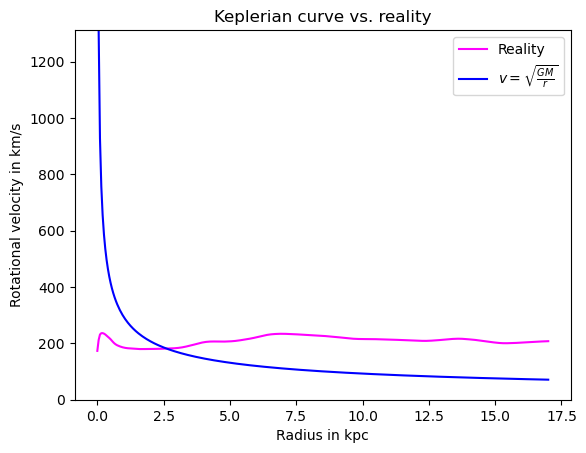

In [2]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G
from math import *

#Reading the file

tilde_path = os.path.expanduser('~')
subdirectory = 'PROGNUM-repo/Task5' 
filename = "rotcur.dat"
path = Path(f"{tilde_path}/{subdirectory}/{filename}")

data = np.loadtxt(path)
x = data[:,0]
y = data[:,1]


#converting the data to np arrays

radius = np.array(x)  #kpc
radius_meters = np.array(x) * (3.086*10**19)  #in m
rotationvelocity = np.array(y) #in km/s

#Calculating the Keplerian rotation curve

M_solar = 2 * 10**10  #solar masses
M_kg = M_solar * 1.989*10**30 #kg
Keplervelocity = []
for i in radius_meters:
        v = sqrt((G * M_kg)/i) / 1000  #meters to km
        Keplervelocity.append(v)

np.savetxt("keplerian_curve.txt", Keplervelocity)
velocity = np.loadtxt("keplerian_curve.txt")
velocity = velocity[1::]  #Gets rid of the inf at the beginning

#plotting the figure

plt.plot(radius, rotationvelocity, color = 'magenta', label = 'Reality')
plt.plot(radius[1::], velocity, color = 'b', label = r'$v = \sqrt{\frac{G M}{r}}$')  #Makes sure by slicing that the values of radius and velocity match
plt.ylim(0, np.max(velocity))  #Creates lower and upper boundary w.r.t. the Keplerian curve
plt.title ("Keplerian curve vs. reality")
plt.xlabel("Radius in kpc")
plt.ylabel("Rotational velocity in km/s")
plt.legend()
plt.show()

#You see in this plot that the calculated rotational velocity doesn't match the observed velocity.
#Instead of the expected decrease, the rotational velocity remains relatively constant.
#This is one of the 'proofs' of dark matter


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

So the mean of this part is 0.01934645907282697.
So the standard deviation of this part is 1.0057209479611549.


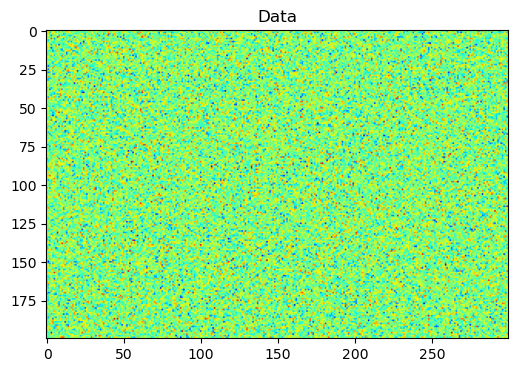

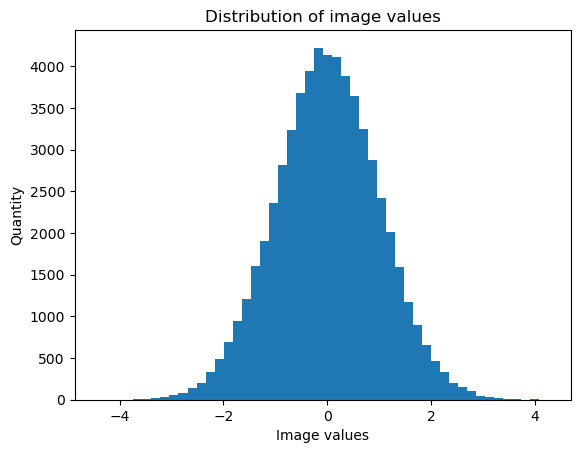

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show

#Making the data

mean = 0
stdev = 1.0
N = 200 * 300
data = np.random.normal(mean, stdev, N)

#making the image

image = data.reshape(200, 300) #making it 2D
plt.figure(figsize = (8, 4))  #Making it 8 by 4 inches)
plt.title("Data")
plt.imshow(image, cmap='jet')

#Taking a small 2D slice:

part = image[:30, 50:80]   # 30x30 pixels
mean_part = part.mean()
stdev_part = part.std()
print(f"So the mean of this part is {mean_part}.")
print(f"So the standard deviation of this part is {stdev_part}.")

#This data differs a bit every time, but it is about mean = 0 and standard deviation = 1. 
#This is what I expected, since the data I asked for had the same mean and standard deviation. 
#Any large enough subdata would have the same characteristics.

#Plotting a histrogram of all image values

data_flat = image.flatten() #flattens the image
plt.figure()
plt.hist(data, bins = 50)
plt.xlabel(f"Image values")
plt.ylabel(f"Quantity")
plt.title(f"Distribution of image values")
plt.show()

#This is a normal distribution.
#This was expected, since I asked for data with a normal distribution.

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

So the area of the ellipse is 18.84955592153876.
So the perimeter of the ellipse is 15.865439589251233.
Center = (0, 0)  Semi-major = 3  Semi-minor = 2  Angle = 30


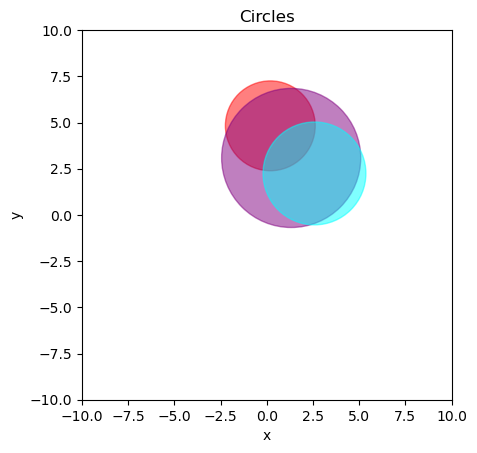

In [6]:
from matplotlib.patches import Ellipse
from math import *
import matplotlib.pyplot as plt
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)
        XY = (xc, yc)
        angle_mpl = position_angle
        self.semi_major =semi_major 
        self.semi_minor = semi_minor
        height = 2.0 * semi_major
        width = 2.0 * semi_minor
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        A = pi * self.semi_major * self.semi_minor  #gives the area
        return A
    def perimeter(self):  #gives the perimeter using Ramanujan's formula
        h = ((self.semi_major - self.semi_minor)**2/(self.semi_major + self.semi_minor)**2)
        P = pi * (self.semi_major + self.semi_minor) * (1 + ((3* h)/(10 + sqrt(4 - 3*h))))
        return (P)
    def __str__(self):
        s = f"Center = {(self.center)}  Semi-major = {self.semi_major}  Semi-minor = {self.semi_minor}  Angle = {self.angle}"
        return s  #prints above when print(AstroEllips() is used

ellipse = AstroEllipse(0, 0, 3, 2, 30)
Area = ellipse.area()
Perimeter = ellipse.perimeter()

print(f"So the area of the ellipse is {Area}.")
print(f"So the perimeter of the ellipse is {Perimeter}.")

print(ellipse) #demonstrates the __str__ method


#Creating a class that inherits from AstroEllipse

class MyCircle(AstroEllipse): #For a circle, both axis are equal
    def __init__(self, xc, yc, radius, **args):  #**args for extra elements, such as color
        super(). __init__(xc, yc, semi_major = radius, semi_minor=radius, position_angle = 0, **args) #All the angles for a circle are equal

 #Creating plot with 3 circles
figure, ax = plt.subplots()
ax.set_aspect('equal')

colors = ['red', 'purple', 'aqua']

for color in colors:
    xc, yc = np.random.uniform(0, 5, 2) #2 for giving 2 numbers
    radius = np.random.uniform(0.1, 4) #gives a random radius
    circle = MyCircle(xc, yc, radius, color = color, alpha = 0.5)  #making the circles
    ax.add_patch(circle)  #adds the circle to the plot

#I think this is what was meant for using the Axes object? 
#I'm not sure where section 5.7 is...
#Configuring the plot
ax.set_xlim(-10, 10) #Making sure the circles are visible
ax.set_ylim(-10, 10) #Making sure the circles are visible
ax.set_title(f"Circles")
ax.set_xlabel ("x")
ax.set_ylabel ("y")
plt.show()


#Each time the radius and position of the circles changes
#You can use np.random.seed(n) to make it standard

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

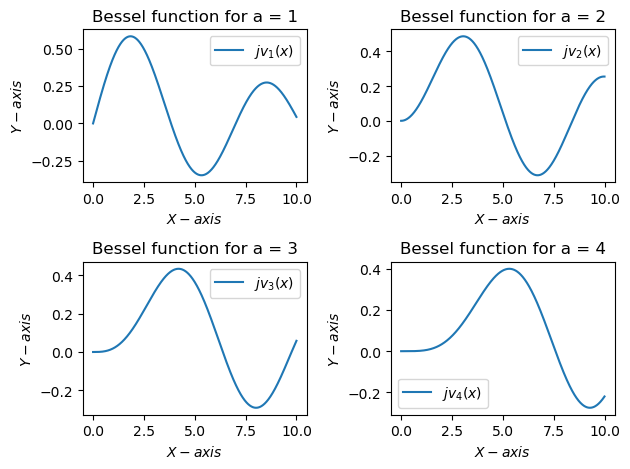

In [8]:
from scipy.special import jv
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.pyplot import figure, show
import numpy as np

x = np.linspace(0, 10, 1000)  #gives x-values
a_values = [1, 2, 3, 4]  #values of a

#Making the grid

fig = figure(tight_layout = True)
gs = gridspec.GridSpec(2, 2)
fr1 = fig.add_subplot(gs[0,0])
fr2 = fig.add_subplot(gs[0,1])
fr3 = fig.add_subplot(gs[1,0])
fr4 = fig.add_subplot(gs[1,1])

frames = [fr1, fr2, fr3, fr4] #makes it possible to loop

for frame, a in zip(frames, a_values):  #plots the values of jv
    y = jv(a, x) #gives the y values
    frame.plot(x, y, label=f"$jv_{a} (x)$" )
    frame.set_title (f"Bessel function for a = {a}")
    frame.set_xlabel("$X-axis$")
    frame.set_ylabel("$Y-axis$")
    frame.legend()

plt.savefig('bessel.png', transparent = True)  #otherwise white background
plt.show()

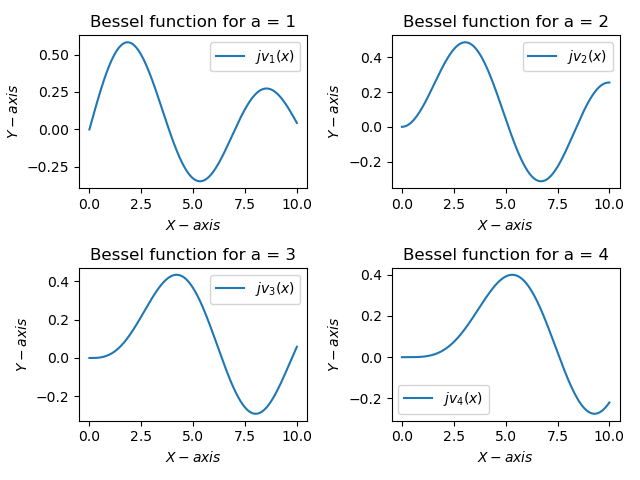

In [9]:
from IPython.display import Image

Image(filename = 'bessel.png')  #displaying the image

In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

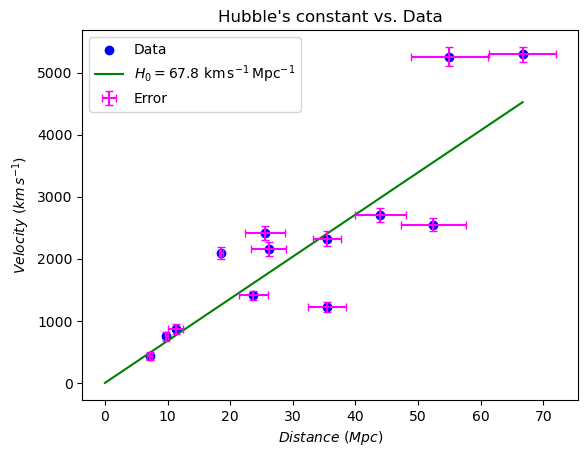

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]


#slicing the data in seperate arrays

data_np = np.array(data)  
distance = data_np[0::4]  #in Mpc, doesn't need to be changed, since H0 is km/s/Mpc
velocity = data_np[1::4]  #in km/s
err_distance = data_np[2::4]  #error in distance
err_velocity = data_np[3::4]  #error in velocity

#making sure the data is in the right order, otherwise the graph is all wonky

order = np.argsort(distance)  #returns the indices that sort the array
distance = distance[order]  #making sure the others are in the same order
velocity = velocity[order]
err_distance = err_distance[order]
err_velocity = err_velocity[order]


#Adding the Hubble relation
maximum = max(distance)  #for the maximum value of x
x = np.linspace(0, maximum, 1000)  #gives a bunch of x-values to give a nice plot
H0 = 67.8
velocity_H0 = H0 * x  #hubble relation

#making the plot
fig = figure()
frame = fig.add_subplot()
frame.scatter(distance, velocity, color = 'b', label = 'Data')  #scatter, because plot is very, very wonky, since it draws straight lines between the points
frame.plot(x, velocity_H0, color = 'g', label = r"$H_0 = 67.8\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$")  #can be a plot, since it is a linear relation
frame.errorbar(distance, velocity, xerr = err_distance, yerr = err_velocity, color = 'magenta', label = "Error", fmt = 'none', capsize = 3)
#fmt = none is necessary, otherwise it also plots the data again... And this is very wonky
frame.set_ylabel(r"$Velocity\ (km\,s^{-1})$")
frame.set_xlabel(r"$Distance\ (Mpc)$")
frame.set_title("Hubble's constant vs. Data")
frame.legend()
show()

In [12]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
